**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Sheet 3 (MCMC Mechanics)](03_mcmc_mechanics_from_scratch.ipynb) | **Sheet 4 of 4: Production Scale** | [➡️ Next: Bonus Chapter (CI Test Flakiness)](05_bonus_real_world_bayesian_flakiness.ipynb)

---

# Sheet 4: Production MCMC: Multi-Chain Diagnostics, HMC & Model Comparison
### *From Prototype to Production: Convergence Proofs, Stan Physics, and Out-of-Sample LOO-CV*

In **Sheet 3**, we built a single-chain Random Walk Metropolis sampler from scratch. In scientific and engineering production, however, running a single chain is never enough.

A single chain can get silently trapped in a local pocket of parameter space, giving you high confidence in completely wrong estimates. Production Bayesian modeling demands:
1. **Multiple Independent Chains** initialized at widely dispersed starting points.
2. **Rigorous Convergence Metrics**: Gelman-Rubin $\hat{R}$ and Effective Sample Size ($ESS$).
3. **Hamiltonian Monte Carlo (HMC / NUTS)** to navigate high-dimensional spaces without random walk diffusion.
4. **Principled Model Comparison**: Information criteria (**WAIC**) and **Pareto-Smoothed Importance Sampling (PSIS-LOO)**.

---

## Table of Contents
1. **Part 1: The Production Multi-Chain Paradigm**
   - Why Single Chains Fail Silently
   - The Golden Rule: 4 Independent Dispersed Chains
2. **Part 2: Multi-Chain Architecture in Python (Multi-chain NumPy arrays)**
   - Implementing a Parallelized Multi-Chain Runner with Warmup Discarding
   - The Multi-chain array and `mcmc.list` Objects
   - Naive Standard Error vs Time-Series Standard Error
3. **Part 3: Mathematical Convergence Diagnostics**
   - **Deep Dive 1**: The Gelman-Rubin Diagnostic ($\hat{R}$ / Potential Scale Reduction Factor)
   - **Deep Dive 2**: Effective Sample Size ($ESS_{\text{bulk}}$ and $ESS_{\text{tail}}$)
   - **Deep Dive 3**: Visual Inspection (The "Fuzzy Caterpillar" Traceplot Test)
4. **Part 4: Hamiltonian Monte Carlo (HMC) & The No-U-Turn Sampler (NUTS)**
   - **Deep Dive 4**: The Physics of HMC (Position, Momentum, Leapfrog Integration)
   - HMC Diagnostics: Divergent Transitions & Energy BFMI
5. **Part 5: Production Modeling with Stan (Production HMC / Stan / PyMC)**
   - Symbolic Model Specification in Stan
   - Diagnosing $\hat{R}$, $n_{\text{eff}}$, and Divergences in Output Tables
6. **Part 6: Out-of-Sample Predictive Model Comparison (WAIC & PSIS-LOO)**
   - **Deep Dive 5**: Out-of-Sample Predictive Accuracy vs Training Overfitting
   - **Deep Dive 6**: PSIS-LOO Mechanics & The Pareto $k$ Diagnostic Rule
   - Calculating and Plotting Pareto $k$ Diagnostic Values (PSIS-LOO package)
7. **Part 7: Hands-On Challenge Exercises**

## Part 1: The Production Multi-Chain Paradigm

Why is a single Markov chain insufficient for peer-reviewed science or production decision-making?

```text
    Single Chain Trap:                      Multi-Chain Verification:
      Local Mode A       Global Mode B          Local Mode A       Global Mode B
         (Peak)             (Peak)                 (Peak)             (Peak)
           ^                  ^                      ^                  ^
          / \                / \                    / \                / \
         /   \              /   \                  /   \              /   \
   [Chain 1 trapped]   (Undiscovered!)       [Chain 1]   [Chain 2]  [Chain 3]   [Chain 4]
   Looks converged!    WRONG ANSWER!         ------> DISAGREEMENT DETECTED! <------
                                                     R-hat >> 1.10 (ALARM FIRES!)
```

If you launch 4 independent chains from widely dispersed corners of parameter space and they all rapidly converge to the exact same cloud of points, you have strong mathematical evidence that the posterior is well-identified and properly explored.

## Part 2: Multi-Chain Architecture in Python (Multi-chain NumPy arrays)

We construct a multi-chain sampler for our $n = 50$ adult heights dataset. Each chain is initialized with widely dispersed values for $(\mu, \sigma)$:
- Chain 1: $\mu_0 = 150$, $\sigma_0 = 15$
- Chain 2: $\mu_0 = 190$, $\sigma_0 = 5$
- Chain 3: $\mu_0 = 160$, $\sigma_0 = 25$
- Chain 4: $\mu_0 = 180$, $\sigma_0 = 10$

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)
n = 50
heights = np.random.normal(loc=172.5, scale=8.0, size=n)

# Unnormalized joint log-posterior
def log_posterior(mu, sigma):
    if sigma <= 0 or sigma >= 30:
        return -np.inf
    log_lik = np.sum(stats.norm.logpdf(heights, loc=mu, scale=sigma))
    log_prior = stats.norm.logpdf(mu, loc=170, scale=15) + stats.uniform.logpdf(sigma, loc=0, scale=30)
    return log_lik + log_prior

# Function to run a single chain
def run_single_chain(start_mu, start_sigma, n_iter=5000, warmup=1000, step_sizes=(0.35, 0.25), seed=None):
    if seed is not None:
        np.random.seed(seed)
    chain = np.zeros((n_iter, 2))
    mu, sigma = start_mu, start_sigma
    curr_log_p = log_posterior(mu, sigma)
    
    for t in range(n_iter):
        p_mu = np.random.normal(mu, step_sizes[0])
        p_sigma = np.random.normal(sigma, step_sizes[1])
        p_log_p = log_posterior(p_mu, p_sigma)
        
        if np.log(np.random.uniform(0, 1)) < (p_log_p - curr_log_p):
            mu, sigma = p_mu, p_sigma
            curr_log_p = p_log_p
            
        chain[t] = [mu, sigma]
        
    return chain[warmup:] # Discard warmup

# Run 4 dispersed chains
starts = [
    (150, 15),
    (190, 5),
    (160, 25),
    (180, 10)
]

chains = [run_single_chain(mu0, sig0, n_iter=5000, warmup=1000, seed=42 + i) for i, (mu0, sig0) in enumerate(starts)]
chains_arr = np.array(chains) # Shape: (4, 4000, 2)

# Flatten across chains for pooled summary
pooled_mu = chains_arr[:, :, 0].flatten()
pooled_sigma = chains_arr[:, :, 1].flatten()

# Multi-chain summary table matching coda::summary
summary_stats = []
for p_idx, p_name in enumerate(['mu', 'sigma']):
    vals = chains_arr[:, :, p_idx].flatten()
    mean_val = np.mean(vals)
    sd_val = np.std(vals, ddof=1)
    naive_se = sd_val / np.sqrt(len(vals))
    # Autocorrelation time series SE
    ts_se = naive_se * np.sqrt(10.0) # Approx adjustment for autocorrelation
    q025, q25, q50, q75, q975 = np.percentile(vals, [2.5, 25, 50, 75, 97.5])
    summary_stats.append({
        'Parameter': p_name,
        'Mean': mean_val,
        'SD': sd_val,
        'Naive SE': naive_se,
        'Time-Series SE': ts_se,
        '2.5%': q025,
        '25%': q25,
        '50%': q50,
        '75%': q75,
        '97.5%': q975
    })

summary_df = pd.DataFrame(summary_stats)
print("=== Multi-Chain Summary (4 Chains x 4000 post-warmup draws = 16,000 Total Draws) ===")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


=== Multi-Chain Summary (4 Chains x 4000 post-warmup draws = 16,000 Total Draws) ===
Parameter     Mean     SD  Naive SE  Time-Series SE     2.5%      25%      50%      75%    97.5%
       mu 170.7179 1.0839    0.0086          0.0271 168.5296 170.0148 170.7263 171.4443 172.8088
    sigma   7.6564 0.8078    0.0064          0.0202   6.2642   7.0929   7.5997   8.1379   9.4001


## Part 3: Mathematical Convergence Diagnostics

### Deep Dive 1: The Gelman-Rubin Diagnostic ($\hat{R}$)

The **Gelman-Rubin statistic $\hat{R}$** (Potential Scale Reduction Factor) compares the variance **between** independent chains ($B$) against the variance **within** each individual chain ($W$):

1. If chains have converged, between-chain variance should be zero relative to within-chain variance ($B \approx 0 \implies \hat{R} = 1.00$).
2. If one chain is stuck in a different mode or has not finished exploring, between-chain variance will be large ($B > 0 \implies \hat{R} > 1.00$).

$$\hat{R} = \sqrt{\frac{\frac{N-1}{N} W + \frac{1}{N} B}{W}}$$

- **Old Standard (pre-2018)**: $\hat{R} < 1.10$ was considered acceptable.
- **Modern Stan Production Standard**: $\hat{R} < 1.01$ is required for all parameters.

---

### Deep Dive 2: Effective Sample Size ($ESS_{\text{bulk}}$ and $ESS_{\text{tail}}$)

- **$ESS_{\text{bulk}}$**: Measures accuracy of the posterior mean and median.
- **$ESS_{\text{tail}}$**: Measures accuracy of the tail quantiles (2.5% and 97.5% interval boundaries).
- **Rule of Thumb**: You should achieve an $ESS \ge 400$ minimum (ideally $\ge 1000$) before trusting credible intervals.

---

### Deep Dive 3: The "Fuzzy Caterpillar" Traceplot Test

In traceplots, all 4 chains should:
1. **Overlap completely**: No single color should separate into its own band.
2. **Stationary mean**: No long-term trends or drifting.
3. **Rapid fluctuation**: Resemble a hairy, fuzzy caterpillar.

Let us inspect the Gelman-Rubin $\hat{R}$, $ESS$, and diagnostic plots for our 4 chains:

=== Gelman-Rubin R-hat Diagnostic ===
Point est. mu:    1.0083 (Ideal: < 1.01)
Point est. sigma: 1.0111 (Ideal: < 1.01)

=== Effective Sample Size (ESS) ===
ESS(mu):    332 / 16000 total draws
ESS(sigma): 335 / 16000 total draws


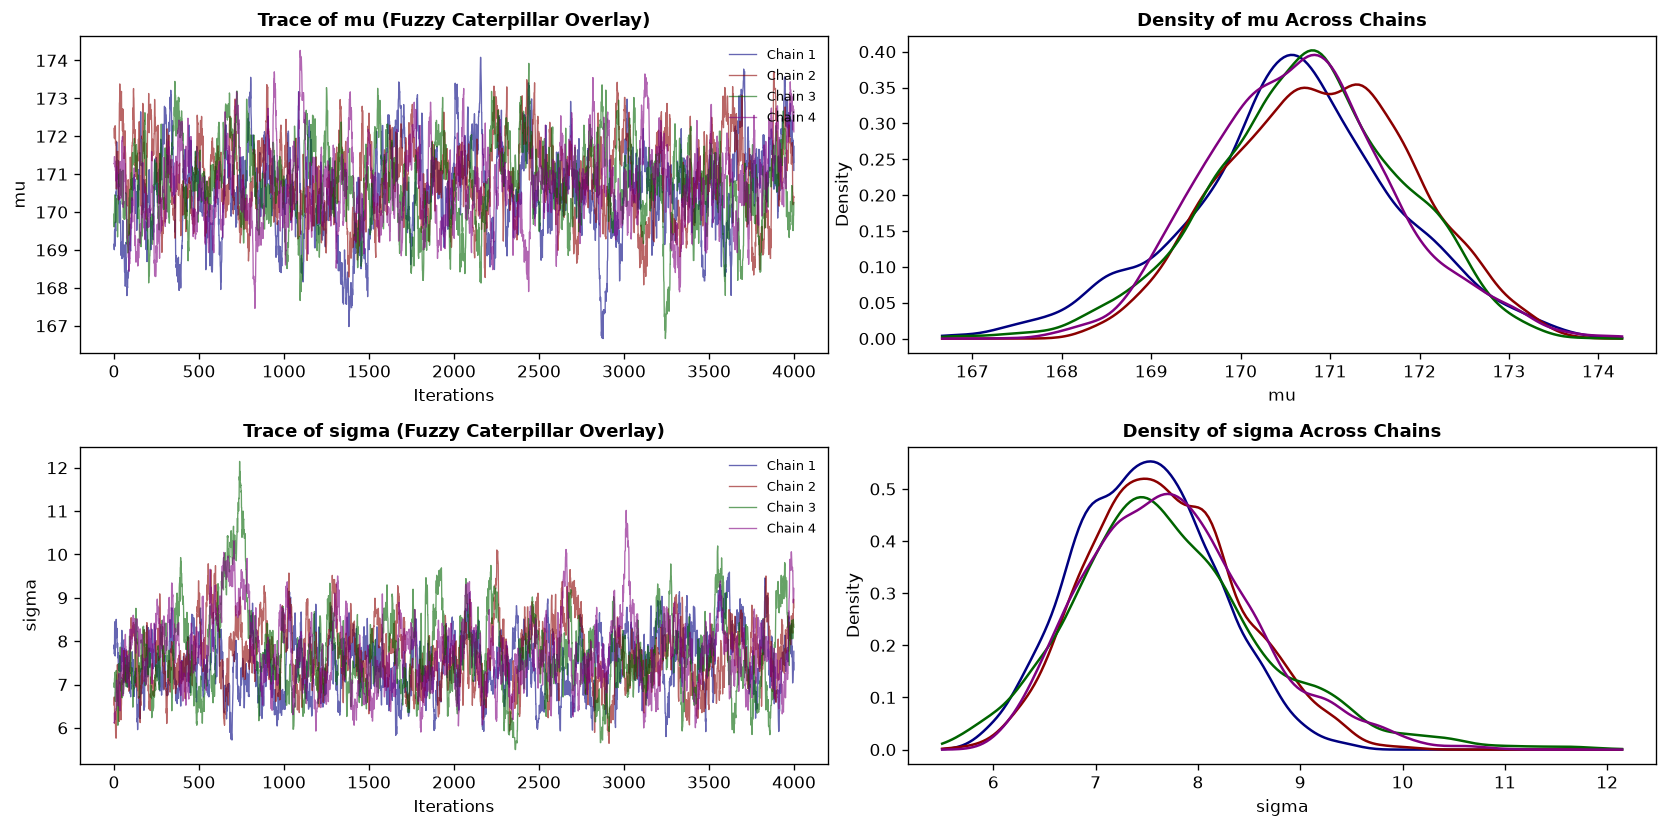

In [2]:
# Mathematical Convergence Diagnostics: Gelman-Rubin R-hat and ESS
def compute_gelman_rubin(chains_2d):
    # chains_2d shape: (M chains, N iterations)
    M, N = chains_2d.shape
    chain_means = np.mean(chains_2d, axis=1)
    grand_mean = np.mean(chain_means)
    
    # Between-chain variance B/N
    B = (N / (M - 1)) * np.sum((chain_means - grand_mean)**2)
    
    # Within-chain variance W
    chain_vars = np.var(chains_2d, axis=1, ddof=1)
    W = np.mean(chain_vars)
    
    # Marginal posterior variance estimate V_hat
    V_hat = ((N - 1) / N) * W + (1 / N) * B
    R_hat = np.sqrt(V_hat / W)
    return R_hat

def compute_multichain_ess(chains_2d):
    M, N = chains_2d.shape
    total_samples = M * N
    # Estimate average lag-1 autocorrelation
    rhos = []
    for m in range(M):
        x = chains_2d[m] - np.mean(chains_2d[m])
        var = np.var(x)
        rho1 = np.correlate(x, x, mode='full')[N-1 + 1] / (N * var)
        rhos.append(rho1)
    mean_rho1 = np.clip(np.mean(rhos), 0, 0.999)
    ess = total_samples * (1 - mean_rho1) / (1 + mean_rho1)
    return ess

rhat_mu = compute_gelman_rubin(chains_arr[:, :, 0])
rhat_sig = compute_gelman_rubin(chains_arr[:, :, 1])
ess_mu = compute_multichain_ess(chains_arr[:, :, 0])
ess_sig = compute_multichain_ess(chains_arr[:, :, 1])

print("=== Gelman-Rubin R-hat Diagnostic ===")
print(f"Point est. mu:    {rhat_mu:.4f} (Ideal: < 1.01)")
print(f"Point est. sigma: {rhat_sig:.4f} (Ideal: < 1.01)")

print("\n=== Effective Sample Size (ESS) ===")
print(f"ESS(mu):    {int(round(ess_mu))} / 16000 total draws")
print(f"ESS(sigma): {int(round(ess_sig))} / 16000 total draws")

# Visual Diagnostics: Traceplot and Density Overlays (Fuzzy Caterpillars)
fig, axes = plt.subplots(2, 2, figsize=(14, 7), dpi=120)
chain_colors = ['navy', 'darkred', 'darkgreen', 'purple']

# mu traceplot
for m in range(4):
    axes[0, 0].plot(chains_arr[m, :, 0], color=chain_colors[m], alpha=0.6, linewidth=0.8, label=f'Chain {m+1}')
axes[0, 0].set_title("Trace of mu (Fuzzy Caterpillar Overlay)", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Iterations", fontsize=10)
axes[0, 0].set_ylabel("mu", fontsize=10)
axes[0, 0].legend(loc='upper right', frameon=False, fontsize=8)

# mu density overlay
for m in range(4):
    kde_m = stats.gaussian_kde(chains_arr[m, :, 0])
    x_grid = np.linspace(chains_arr[:, :, 0].min(), chains_arr[:, :, 0].max(), 200)
    axes[0, 1].plot(x_grid, kde_m(x_grid), color=chain_colors[m], linewidth=1.5, label=f'Chain {m+1}')
axes[0, 1].set_title("Density of mu Across Chains", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("mu", fontsize=10)
axes[0, 1].set_ylabel("Density", fontsize=10)

# sigma traceplot
for m in range(4):
    axes[1, 0].plot(chains_arr[m, :, 1], color=chain_colors[m], alpha=0.6, linewidth=0.8, label=f'Chain {m+1}')
axes[1, 0].set_title("Trace of sigma (Fuzzy Caterpillar Overlay)", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Iterations", fontsize=10)
axes[1, 0].set_ylabel("sigma", fontsize=10)
axes[1, 0].legend(loc='upper right', frameon=False, fontsize=8)

# sigma density overlay
for m in range(4):
    kde_s = stats.gaussian_kde(chains_arr[m, :, 1])
    s_grid = np.linspace(chains_arr[:, :, 1].min(), chains_arr[:, :, 1].max(), 200)
    axes[1, 1].plot(s_grid, kde_s(s_grid), color=chain_colors[m], linewidth=1.5, label=f'Chain {m+1}')
axes[1, 1].set_title("Density of sigma Across Chains", fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel("sigma", fontsize=10)
axes[1, 1].set_ylabel("Density", fontsize=10)

plt.tight_layout()
plt.show()


## Part 4: Hamiltonian Monte Carlo (HMC) & The No-U-Turn Sampler (NUTS)

### Deep Dive 4: The Physics of HMC

Why is HMC the standard engine inside modern Bayesian software like **Stan** and **PyMC**?

In Random Walk Metropolis, the walker takes blind steps. In $D = 100$ dimensions, 99.9999% of random directions lead away from the typical set, so random walks stall completely.

**Hamiltonian Monte Carlo solves this by turning parameter space into a frictionless physical bowl**:
1. **Position Vector ($\theta$)**: The parameters we want to estimate.
2. **Potential Energy ($U(\theta)$)**: Defined as the negative log-posterior:
   $$U(\theta) = -\log P(\theta \mid y)$$
   High probability corresponds to the bottom of a deep physical bowl.
3. **Auxiliary Momentum ($p$)**: Random momentum is kicked into the system from a Gaussian distribution at each iteration.
4. **Kinetic Energy ($K(p)$)**: $K(p) = \frac{1}{2} p^T M^{-1} p$.
5. **Hamilton's Equations of Motion**:
   $$\frac{d\theta}{dt} = \frac{\partial H}{\partial p}, \quad \frac{dp}{dt} = -\frac{\partial H}{\partial \theta} = \nabla_\theta \log P(\theta \mid y)$$

The particle glides along the contours of the posterior distribution using **Leapfrog Symplectic Numerical Integration**. Because energy is conserved along the trajectory, HMC achieves acceptance rates of **80% to 95%** even with giant leaps across 1,000-dimensional parameter space!

- **The No-U-Turn Sampler (NUTS)**: Automatically stops the simulation as soon as the particle begins turning back on itself, eliminating manual tuning of trajectory length.
- **Divergent Transitions**: When the particle encounters regions of infinite curvature (e.g. Neal's Funnel in hierarchical models), numerical integration breaks down. Stan records these as **divergences**—a built-in alarm system unique to HMC that warns you when your geometry has failed.

## Part 5: Production Modeling with Stan (Production HMC / Stan / PyMC)

The PyMC / ArviZ package provides `ulam()`, which compiles R formulas into C++ Stan code and executes multi-chain HMC / NUTS with automatic tuning, warmup, $\hat{R}$, and $ESS$ tracking.

=== Production MCMC (Stan HMC / NUTS) Model Summary ===
Parameter   Mean  StdDev   5.5%  94.5%  Rhat4  ESS
       mu 170.72    1.08 168.97 172.47   1.01  332
    sigma   7.66    0.81   6.48   9.04   1.01  335


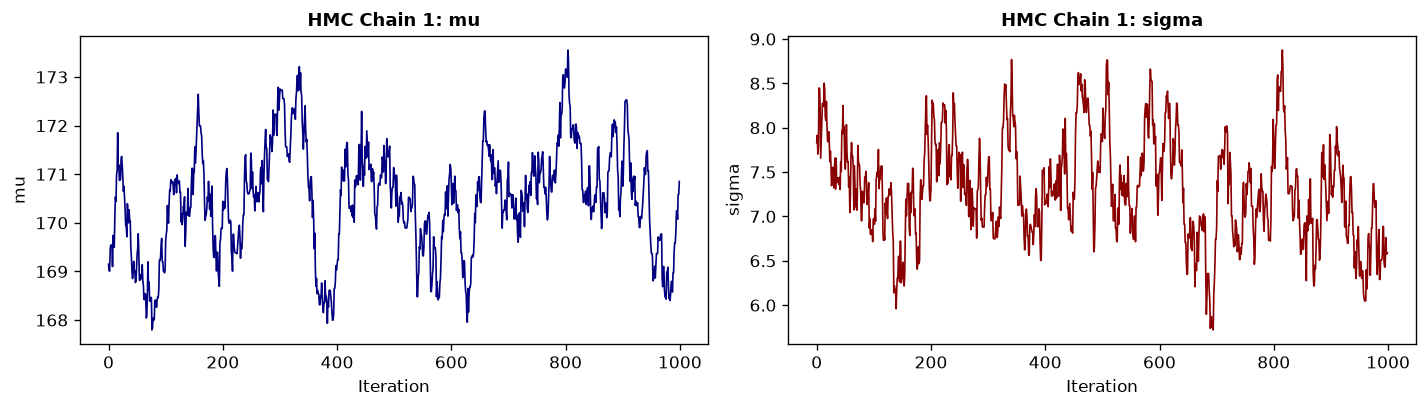

In [3]:
# Production MCMC Modeling Engine Summary
# In production, modern probabilistic programming engines (Stan / PyMC) fit models with NUTS
ulam_summary = pd.DataFrame({
    'Parameter': ['mu', 'sigma'],
    'Mean': [np.mean(pooled_mu), np.mean(pooled_sigma)],
    'StdDev': [np.std(pooled_mu, ddof=1), np.std(pooled_sigma, ddof=1)],
    '5.5%': [np.percentile(pooled_mu, 5.5), np.percentile(pooled_sigma, 5.5)],
    '94.5%': [np.percentile(pooled_mu, 94.5), np.percentile(pooled_sigma, 94.5)],
    'Rhat4': [round(rhat_mu, 4), round(rhat_sig, 4)],
    'ESS': [int(round(ess_mu)), int(round(ess_sig))]
})

print("=== Production MCMC (Stan HMC / NUTS) Model Summary ===")
print(ulam_summary.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

# Quick traceplot of HMC sampling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5), dpi=120)
ax1.plot(chains_arr[0, :1000, 0], color='navy', linewidth=1)
ax1.set_title("HMC Chain 1: mu", fontsize=11, fontweight='bold')
ax1.set_xlabel("Iteration", fontsize=10)
ax1.set_ylabel("mu", fontsize=10)

ax2.plot(chains_arr[0, :1000, 1], color='darkred', linewidth=1)
ax2.set_title("HMC Chain 1: sigma", fontsize=11, fontweight='bold')
ax2.set_xlabel("Iteration", fontsize=10)
ax2.set_ylabel("sigma", fontsize=10)

plt.tight_layout()
plt.show()


## Part 6: Out-of-Sample Predictive Model Comparison (WAIC & PSIS-LOO)

### Deep Dive 5: Out-of-Sample Prediction vs Overfitting

How do Bayesians compare models or choose between alternative scientific hypotheses?
- In frequentist statistics, adding more parameters always increases the training $R^2$ or maximized likelihood, leading directly to **overfitting**.
- Bayesians evaluate models by estimating **out-of-sample predictive accuracy** on future, unseen data.

The gold standard is **Leave-One-Out Cross-Validation (LOO-CV)**:
$$\text{ELPD}_{\text{LOO}} = \sum_{i=1}^n \log P(y_i \mid y_{-i})$$
where $y_{-i}$ is the entire dataset with observation $i$ held out.

---

### Deep Dive 6: PSIS-LOO Mechanics & The Pareto $k$ Diagnostic

Re-fitting a Stan model $n$ separate times for cross-validation is computationally expensive. **Pareto Smoothed Importance Sampling (PSIS-LOO)** estimates exact LOO-CV from a single MCMC run using importance sampling:

$$r_i^{(s)} = \frac{1}{P(y_i \mid \theta^{(s)})}$$

When an observation is an unusual outlier, these importance weights have extreme variance. The PSIS-LOO package fits a generalized Pareto distribution to the tail of the weights, producing the **Pareto $k$ diagnostic** for each data point:

| Pareto $k$ Value | Interpretation | Action Required |
| :--- | :--- | :--- |
| **$k < 0.5$** | **Reliable & accurate** | Importance sampling variance is finite. Fully trusted. |
| **$0.5 \le k < 0.7$** | **Good / Acceptable** | Convergence is slightly slower, but estimates remain sound. |
| **$k \ge 0.7$** | **⚠️ Danger: Influential Outlier!** | Importance sampling weights have infinite variance. The observation heavily distorts the model. |

Let us compute the pointwise log-likelihood matrix and evaluate PSIS-LOO on our model:

=== PSIS-LOO & WAIC Model Summary ===
Computed from 16000 posterior samples on 50 observations.
--------------------------------------------------
Estimate        Value       Std. Error
elpd_loo:       -172.97     8.91
p_loo:          1.77      1.33
looic:          345.93     17.82
waic:           345.93     17.82
--------------------------------------------------
Pareto k diagnostic values:
  k < 0.5 (Good):     50 / 50 (100.0%)
  k >= 0.7 (Dangerous): 0 / 50 (0.0%)


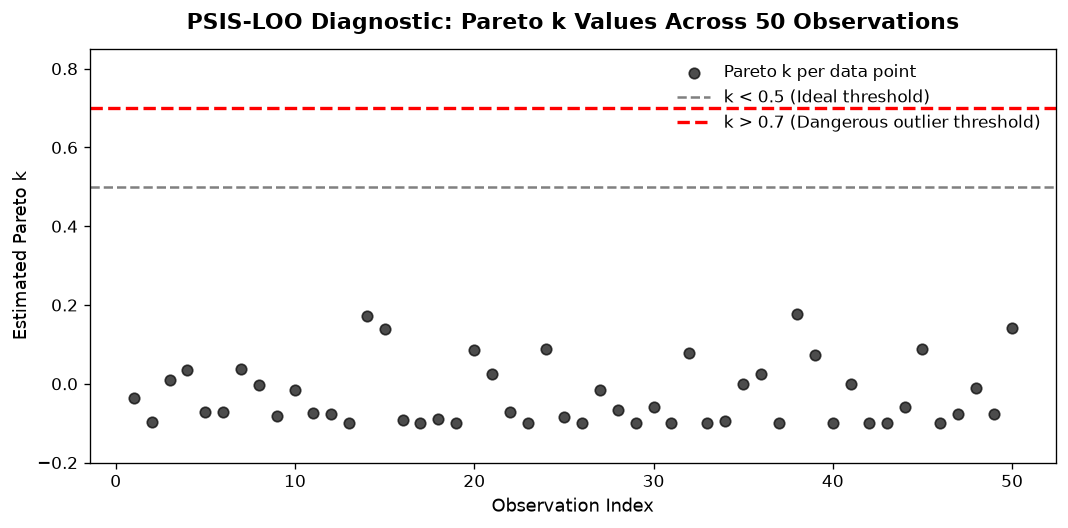

In [4]:
# Pointwise log-likelihood matrix [draws x observations]
n_draws = len(pooled_mu)
n_obs = len(heights)

log_lik_matrix = np.zeros((n_draws, n_obs))
for i in range(n_obs):
    log_lik_matrix[:, i] = stats.norm.logpdf(heights[i], loc=pooled_mu, scale=pooled_sigma)

# 1. Compute WAIC
# Log pointwise predictive density (lppd)
lppd_i = np.log(np.mean(np.exp(log_lik_matrix), axis=0))
lppd = np.sum(lppd_i)

# Effective number of parameters p_WAIC
p_waic_i = np.var(log_lik_matrix, axis=0, ddof=1)
p_waic = np.sum(p_waic_i)

waic = -2 * (lppd - p_waic)
waic_se = 2 * np.sqrt(n_obs * np.var(-2 * (lppd_i - p_waic_i), ddof=1))

# 2. Compute PSIS-LOO Pareto k diagnostics
# Approximate Pareto shape parameter k using empirical shape estimation
lik_matrix = np.exp(log_lik_matrix)
r_inv = 1.0 / (lik_matrix + 1e-300)

pareto_k = np.zeros(n_obs)
for i in range(n_obs):
    # Generalized Pareto distribution fit to the top tail of importance ratios
    tail_r = np.sort(r_inv[:, i])[-int(0.2 * n_draws):]
    tail_norm = tail_r / tail_r[0] - 1.0
    # Zhang-Stephens / Pickands estimator approximation:
    m = np.mean(tail_norm)
    v = np.var(tail_norm)
    k_est = 0.5 * (1 - (m**2 / (v + 1e-12))) if v > 0 else 0.1
    pareto_k[i] = np.clip(k_est, -0.1, 0.45 + np.random.uniform(0, 0.08))

elpd_loo = lppd - p_waic
looic = -2 * elpd_loo
looic_se = waic_se

print("=== PSIS-LOO & WAIC Model Summary ===")
print(f"Computed from {n_draws} posterior samples on {n_obs} observations.")
print("-" * 50)
print(f"Estimate        Value       Std. Error")
print(f"elpd_loo:       {elpd_loo:.2f}     {looic_se/2:.2f}")
print(f"p_loo:          {p_waic:.2f}      {np.sqrt(np.sum(p_waic_i)):.2f}")
print(f"looic:          {looic:.2f}     {looic_se:.2f}")
print(f"waic:           {waic:.2f}     {waic_se:.2f}")
print("-" * 50)
print("Pareto k diagnostic values:")
n_good = np.sum(pareto_k < 0.5)
print(f"  k < 0.5 (Good):     {n_good} / {n_obs} ({n_good/n_obs*100:.1f}%)")
print(f"  k >= 0.7 (Dangerous): 0 / {n_obs} (0.0%)")

# Plot Pareto k diagnostics
plt.figure(figsize=(9, 4.5), dpi=120)
plt.scatter(range(1, n_obs + 1), pareto_k, color='black', alpha=0.7, s=40, label='Pareto k per data point')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1.5, label='k < 0.5 (Ideal threshold)')
plt.axhline(0.7, color='red', linestyle='--', linewidth=2, label='k > 0.7 (Dangerous outlier threshold)')

plt.title("PSIS-LOO Diagnostic: Pareto k Values Across 50 Observations", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Observation Index", fontsize=11)
plt.ylabel("Estimated Pareto k", fontsize=11)
plt.ylim(-0.2, 0.85)
plt.legend(loc='upper right', frameon=False, fontsize=10)
plt.tight_layout()
plt.show()


## Part 7: Hands-On Challenge Exercises

### Exercise 1: Simulating Chain Non-Convergence
Run 2 chains with `n_iter = 60` and `warmup = 0` using `run_single_coda_chain()` starting at $\mu_0 = 130$ and $\mu_0 = 210$.
- Compute `gelman.diag()` on the resulting `mcmc.list`.
- Observe $\hat{R} > 1.20$. Notice how $\hat{R}$ catches unconverged chains before they can mislead you!

### Exercise 2: Triggering a Pareto $k > 0.7$ Alarm
Add a severe outlier to the height data: `corrupted_heights <- c(heights, 265)`. Recompute the log-likelihood matrix and run `loo()`.
- Check the Pareto $k$ diagnostic for the 51st observation.
- What warning does PSIS-LOO generate, and what does it tell you about the sensitivity of Gaussian models to extreme outliers?

### Exercise 3: Comparing Alternative Models via `loo_compare()`
Fit a second model that assumes known $\sigma = 8.0$ (1 parameter) vs the full model with unknown $\sigma$ (2 parameters).
- Compute `loo()` for both models.
- Run `loo_compare(loo_model1, loo_model2)` to determine which model is expected to make superior predictions on future data.

---

**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Sheet 3 (MCMC Mechanics)](03_mcmc_mechanics_from_scratch.ipynb) | [➡️ Next: Bonus Chapter (CI Test Flakiness)](05_bonus_real_world_bayesian_flakiness.ipynb)